In [ ]:
# ============================================================
# MODULE 2 - TITANIC MACHINE LEARNING
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

# IMPORTANT:

# We use the CSV created by 01_eda.ipynb.

df = pd.read_csv("titanic.csv")

print("Dataset shape:", df.shape)
df.head()

Libraries imported successfully.
Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [20]:
# ============================================================
# CLASSIFICATION FEATURES AND TARGET
# ============================================================

classification_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

target = "survived"

X = df[classification_features].copy()
y = df[target].copy()

print("Features:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

X shape: (891, 7)
y shape: (891,)

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64

Target percentage:
survived
0    61.62
1    38.38
Name: proportion, dtype: float64


In [21]:
# ============================================================
# STRATIFIED TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target percentages:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nTesting target percentages:")
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

X_train shape: (712, 7)
X_test shape: (179, 7)
y_train shape: (712,)
y_test shape: (179,)

Training target percentages:
survived
0    61.66
1    38.34
Name: proportion, dtype: float64

Testing target percentages:
survived
0    61.45
1    38.55
Name: proportion, dtype: float64


### Stratified Train/Test Split

The dataset was split into training and testing sets before fitting any preprocessing transformations. Stratification was performed using the survival target so that the class proportions remain similar in both datasets. This ordering helps prevent information from the test set from leaking into preprocessing fitted on the training data.

In [22]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Preprocessing pipeline created successfully.
Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


In [23]:
# ============================================================
# LOGISTIC REGRESSION
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train using training data only
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [24]:
# ============================================================
# DECISION TREE CLASSIFIER
# ============================================================

decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=4,
                random_state=42
            )
        )
    ]
)

decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [13]:
print("Logistic Regression:", type(logistic_pipeline).__name__)
print("Decision Tree:", type(decision_tree_pipeline).__name__)
print("Random Forest:", type(random_forest_pipeline).__name__)

Logistic Regression: Pipeline
Decision Tree: Pipeline
Random Forest: Pipeline


In [25]:
# ============================================================
# DECISION TREE CLASSIFIER
# ============================================================

decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=4,
                random_state=42
            )
        )
    ]
)

decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [26]:
# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [27]:
# ============================================================
# CLASSIFIER EVALUATION FUNCTION
# ============================================================

def evaluate_classifier(
    model_name,
    model,
    X_test,
    y_test
):
    # Predicted classes
    y_pred = model.predict(X_test)

    # Probability of class 1 (survived)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }


print("Evaluation function created successfully.")

Evaluation function created successfully.


In [28]:
# ============================================================
# EVALUATE ALL CLASSIFIERS
# ============================================================

classification_results = []

classification_results.append(
    evaluate_classifier(
        "Logistic Regression",
        logistic_pipeline,
        X_test,
        y_test
    )
)

classification_results.append(
    evaluate_classifier(
        "Decision Tree",
        decision_tree_pipeline,
        X_test,
        y_test
    )
)

classification_results.append(
    evaluate_classifier(
        "Random Forest",
        random_forest_pipeline,
        X_test,
        y_test
    )
)

classification_results_df = pd.DataFrame(
    classification_results
)

classification_results_df = (
    classification_results_df
    .set_index("Model")
    .round(4)
)

print("Classifier Comparison:")
display(classification_results_df)

Classifier Comparison:


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
Decision Tree,0.7933,0.8636,0.5507,0.6726,0.8292
Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300


In [29]:
# ============================================================
# MODEL DICTIONARY
# ============================================================

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

print("Models dictionary created successfully.")

for model_name in models:
    print("-", model_name)

Models dictionary created successfully.
- Logistic Regression
- Decision Tree
- Random Forest



Confusion Matrix - Logistic Regression
[[98 12]
 [23 46]]


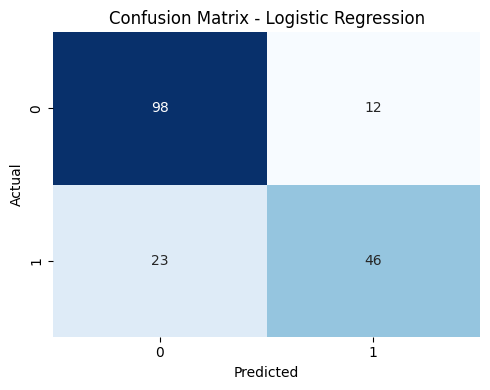


Confusion Matrix - Decision Tree
[[104   6]
 [ 31  38]]


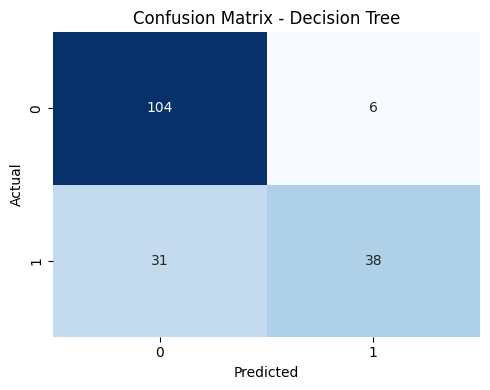


Confusion Matrix - Random Forest
[[98 12]
 [21 48]]


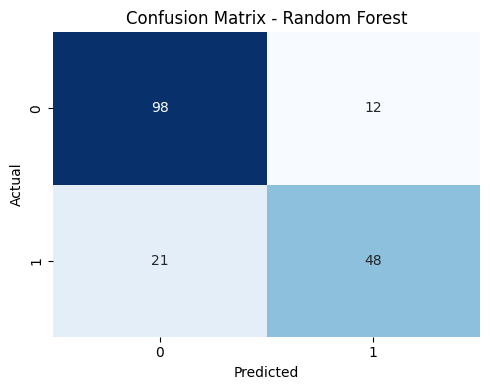

In [30]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

for model_name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print(f"\nConfusion Matrix - {model_name}")
    print(cm)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        f"charts/confusion_matrix_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

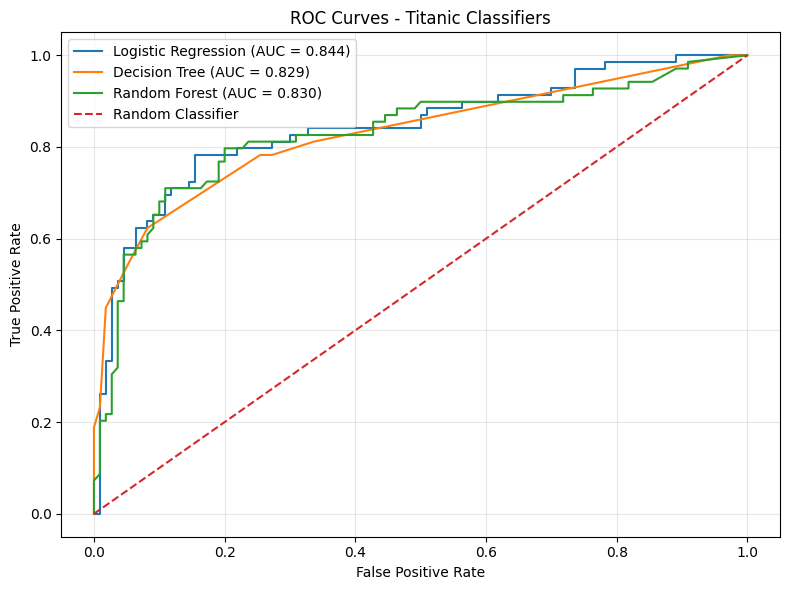

In [31]:
# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{model_name} "
            f"(AUC = {auc_score:.3f})"
        )
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves - Titanic Classifiers"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/classifier_roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

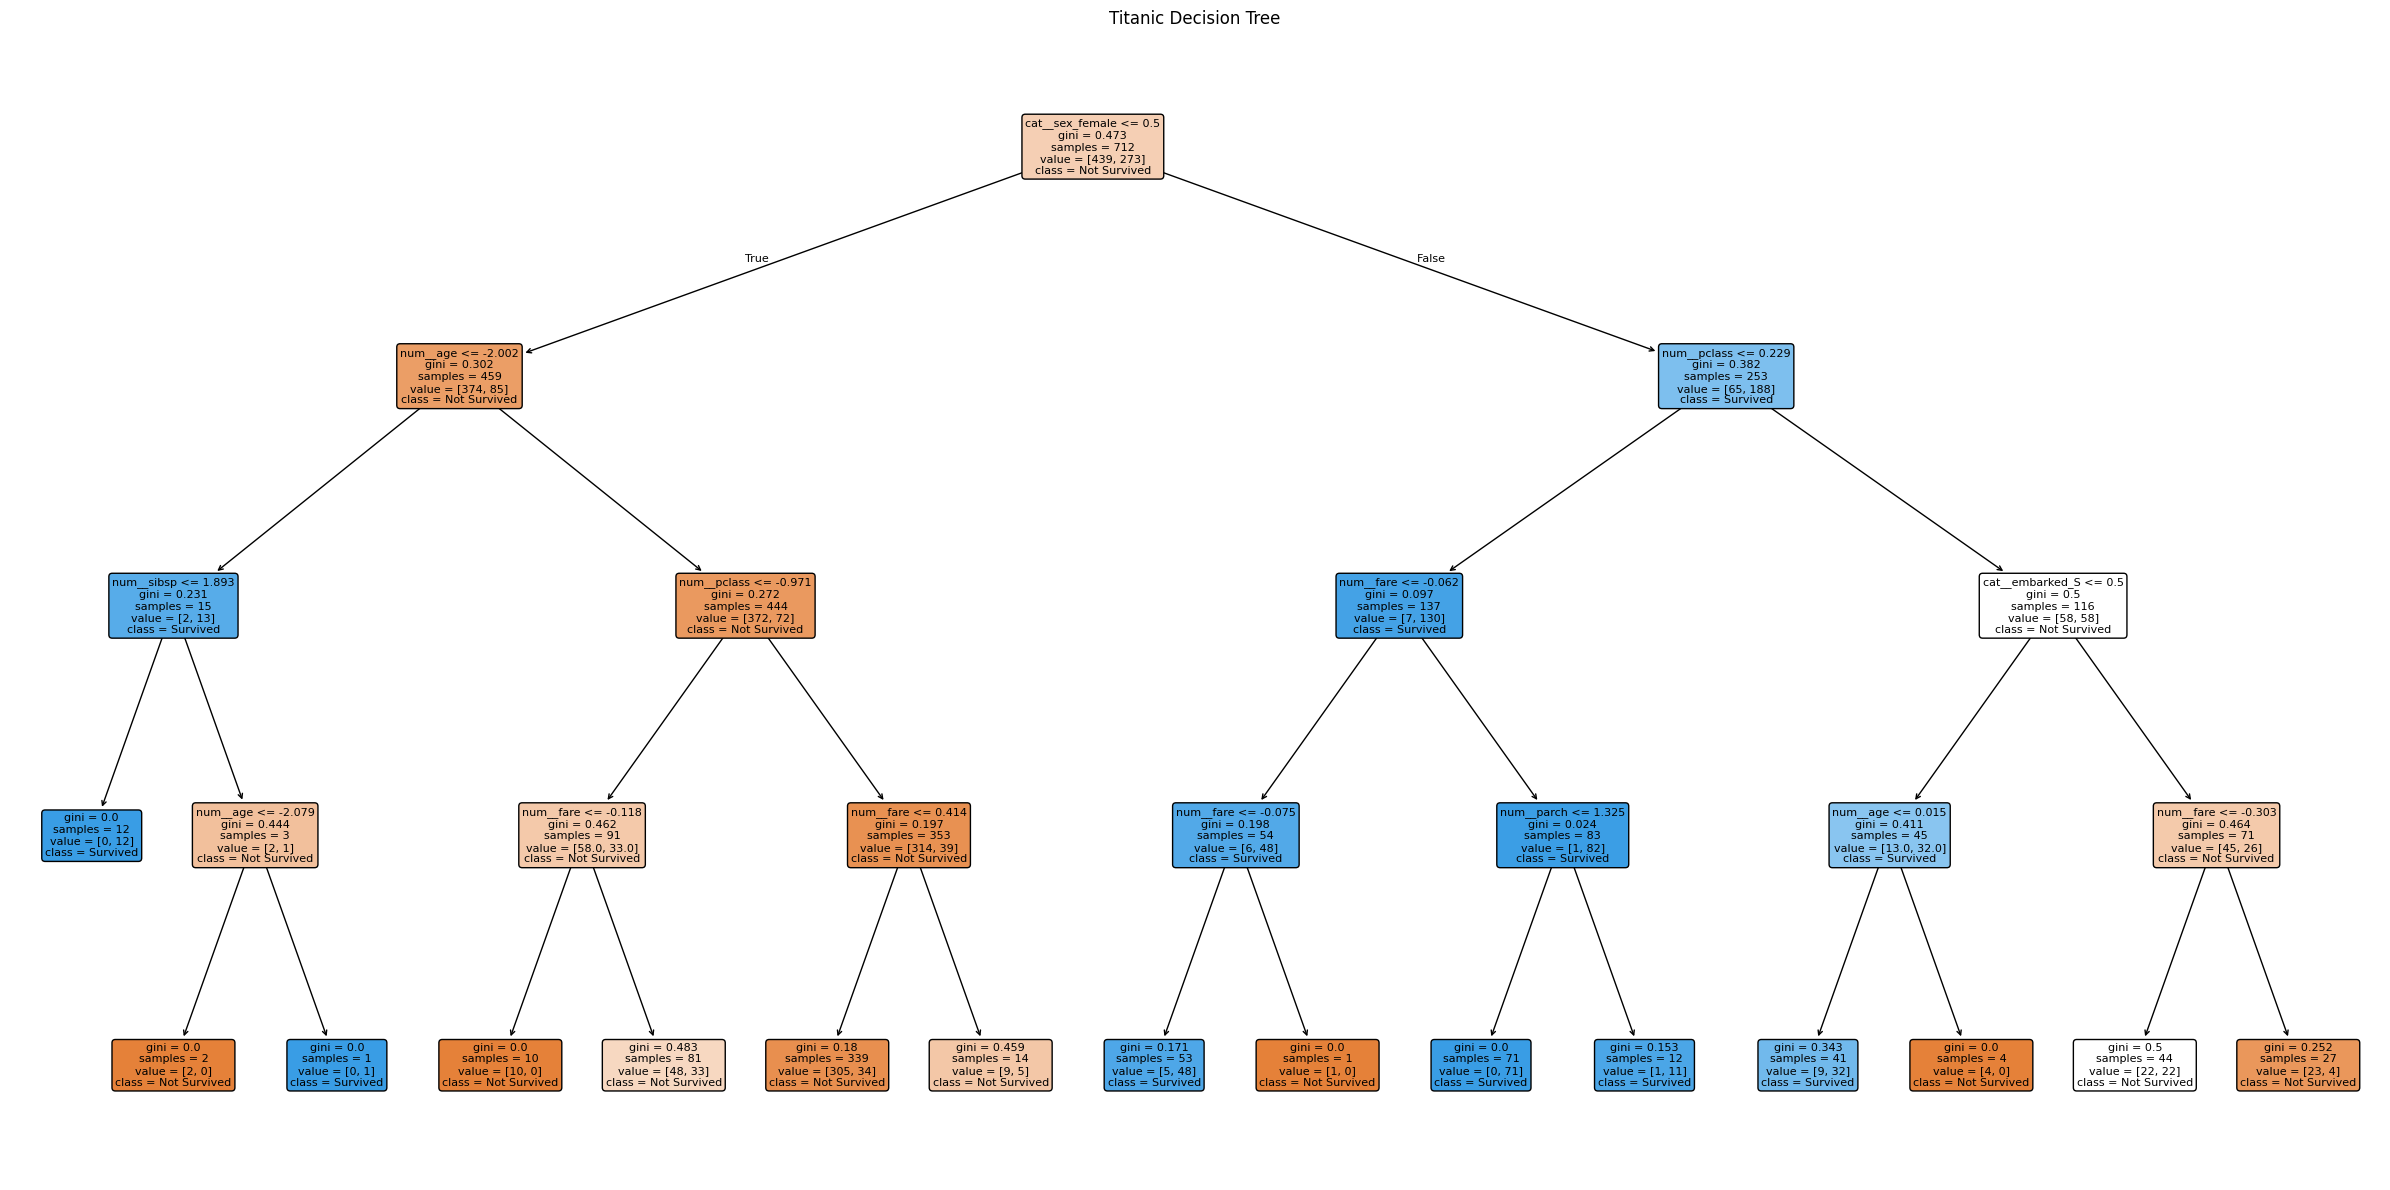

In [32]:
# ============================================================
# DECISION TREE VISUALIZATION
# ============================================================

# Obtain feature names generated by preprocessing
feature_names = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Obtain the trained Decision Tree
tree_model = (
    decision_tree_pipeline
    .named_steps["classifier"]
)

plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[
        "Not Survived",
        "Survived"
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Titanic Decision Tree"
)

plt.tight_layout()

plt.savefig(
    "charts/decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Initial Classifier Evaluation

The classification models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Logistic Regression provides a strong balance between classification performance and discrimination ability, while Decision Tree provides an interpretable tree-based model. Random Forest combines multiple decision trees and can capture more complex relationships in the data.

The comparison demonstrates that model performance should be assessed using multiple metrics rather than accuracy alone. Precision measures the reliability of positive predictions, recall measures the ability to identify surviving passengers, F1-score balances precision and recall, and ROC-AUC evaluates the model's ability to distinguish between the two classes.

In [33]:
# ============================================================
# CLASS IMBALANCE ANALYSIS
# ============================================================

class_counts = y_train.value_counts()

class_percentages = (
    y_train.value_counts(normalize=True) * 100
).round(2)

print("Training Class Counts:")
print(class_counts)

print("\nTraining Class Percentages:")
print(class_percentages)

Training Class Counts:
survived
0    439
1    273
Name: count, dtype: int64

Training Class Percentages:
survived
0    61.66
1    38.34
Name: proportion, dtype: float64


In [34]:
# ============================================================
# BASELINE LOGISTIC REGRESSION
# ============================================================

baseline_predictions = logistic_pipeline.predict(
    X_test
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions
)

print("Baseline Logistic Regression")
print(
    "Precision:",
    round(baseline_precision, 4)
)
print(
    "Recall:",
    round(baseline_recall, 4)
)
print(
    "F1 Score:",
    round(baseline_f1, 4)
)

Baseline Logistic Regression
Precision: 0.7931
Recall: 0.6667
F1 Score: 0.7244


In [35]:
# ============================================================
# LOGISTIC REGRESSION WITH CLASS WEIGHT
# ============================================================

balanced_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_logistic_pipeline.fit(
    X_train,
    y_train
)

balanced_predictions = (
    balanced_logistic_pipeline.predict(
        X_test
    )
)

balanced_precision = precision_score(
    y_test,
    balanced_predictions
)

balanced_recall = recall_score(
    y_test,
    balanced_predictions
)

balanced_f1 = f1_score(
    y_test,
    balanced_predictions
)

print(
    "Class-Weighted Logistic Regression"
)

print(
    "Precision:",
    round(balanced_precision, 4)
)

print(
    "Recall:",
    round(balanced_recall, 4)
)

print(
    "F1 Score:",
    round(balanced_f1, 4)
)

Class-Weighted Logistic Regression
Precision: 0.7297
Recall: 0.7826
F1 Score: 0.7552


In [36]:
# ============================================================
# IMPORT SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully.")

SMOTE imported successfully.


In [37]:
# ============================================================
# SMOTE - TRAINING DATA ONLY
# ============================================================

# Fit preprocessing using TRAINING DATA ONLY
X_train_processed = (
    preprocessor.fit_transform(X_train)
)

# Transform test data using the preprocessing
# learned from the training data
X_test_processed = (
    preprocessor.transform(X_test)
)

print(
    "Training shape before SMOTE:",
    X_train_processed.shape
)

print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

# Create SMOTE
smote = SMOTE(
    random_state=42
)

# Apply SMOTE ONLY to training data
X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_processed,
        y_train
    )
)

print(
    "\nTraining shape after SMOTE:",
    X_train_smote.shape
)

print("\nClass distribution after SMOTE:")
print(
    pd.Series(y_train_smote)
    .value_counts()
)

Training shape before SMOTE: (712, 10)

Class distribution before SMOTE:
survived
0    439
1    273
Name: count, dtype: int64

Training shape after SMOTE: (878, 10)

Class distribution after SMOTE:
survived
1    439
0    439
Name: count, dtype: int64


In [38]:
# ============================================================
# LOGISTIC REGRESSION USING SMOTE DATA
# ============================================================

smote_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_logistic_model.fit(
    X_train_smote,
    y_train_smote
)

smote_predictions = (
    smote_logistic_model.predict(
        X_test_processed
    )
)

smote_precision = precision_score(
    y_test,
    smote_predictions
)

smote_recall = recall_score(
    y_test,
    smote_predictions
)

smote_f1 = f1_score(
    y_test,
    smote_predictions
)

print("SMOTE Logistic Regression")

print(
    "Precision:",
    round(smote_precision, 4)
)

print(
    "Recall:",
    round(smote_recall, 4)
)

print(
    "F1 Score:",
    round(smote_f1, 4)
)

SMOTE Logistic Regression
Precision: 0.7397
Recall: 0.7826
F1 Score: 0.7606


In [39]:
# ============================================================
# CLASS IMBALANCE COMPARISON
# ============================================================

imbalance_results = pd.DataFrame(
    {
        "Method": [
            "Baseline",
            "Class Weight Balanced",
            "SMOTE"
        ],
        "Precision": [
            baseline_precision,
            balanced_precision,
            smote_precision
        ],
        "Recall": [
            baseline_recall,
            balanced_recall,
            smote_recall
        ],
        "F1": [
            baseline_f1,
            balanced_f1,
            smote_f1
        ]
    }
)

imbalance_results = (
    imbalance_results
    .set_index("Method")
    .round(4)
)

print(
    "Class Imbalance Comparison:"
)

display(
    imbalance_results
)

Class Imbalance Comparison:


,Precision,Recall,F1
Method,,,
Baseline,0.7931,0.6667,0.7244
Class Weight Balanced,0.7297,0.7826,0.7552
SMOTE,0.7397,0.7826,0.7606


In [40]:
# ============================================================
# RANDOM FOREST GRID SEARCH
# ============================================================

rf_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                oob_score=True
            )
        )
    ]
)

param_grid = {
    "classifier__n_estimators": [
        100,
        200
    ],
    "classifier__max_depth": [
        None,
        5,
        10
    ],
    "classifier__max_features": [
        "sqrt",
        "log2"
    ]
}

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

print("Grid Search completed successfully.")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid Search completed successfully.


In [41]:
# ============================================================
# BEST RANDOM FOREST PARAMETERS
# ============================================================

best_rf_pipeline = (
    grid_search.best_estimator_
)

best_rf_classifier = (
    best_rf_pipeline
    .named_steps["classifier"]
)

print("Best Parameters:")
print(
    grid_search.best_params_
)

print(
    "\nBest Cross-Validation F1:",
    round(
        grid_search.best_score_,
        4
    )
)

print(
    "\nOOB Score:",
    round(
        best_rf_classifier.oob_score_,
        4
    )
)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best Cross-Validation F1: 0.7459

OOB Score: 0.8272


In [42]:
# ============================================================
# EVALUATE TUNED RANDOM FOREST
# ============================================================

tuned_rf_result = evaluate_classifier(
    "Tuned Random Forest",
    best_rf_pipeline,
    X_test,
    y_test
)

tuned_rf_results_df = pd.DataFrame(
    [tuned_rf_result]
)

tuned_rf_results_df = (
    tuned_rf_results_df
    .set_index("Model")
    .round(4)
)

print(
    "Tuned Random Forest Test Performance:"
)

display(
    tuned_rf_results_df
)

Tuned Random Forest Test Performance:


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Tuned Random Forest,0.8156,0.875,0.6087,0.7179,0.8431


### Random Forest Hyperparameter Tuning

Random Forest was tuned using GridSearchCV over `n_estimators`, `max_depth`, and `max_features`. The tuned model achieved an accuracy of **0.8156**, precision of **0.8750**, recall of **0.6087**, F1-score of **0.7179**, and ROC-AUC of **0.8431** on the test set.

The tuned model achieved high precision, indicating that a large proportion of passengers predicted as survivors were actually survivors. However, the lower recall indicates that the model missed some passengers who actually survived. Therefore, the final model selection will consider multiple evaluation metrics rather than accuracy or precision alone.

In [43]:
# ============================================================
# FARE REGRESSION - PREPARE DATA
# ============================================================

regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

regression_target = "fare"

X_reg = df[regression_features].copy()
y_reg = df[regression_target].copy()

print("Regression Features:")
print(regression_features)

print("\nTarget:")
print(regression_target)

print("\nX shape:", X_reg.shape)
print("y shape:", y_reg.shape)

Regression Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']

Target:
fare

X shape: (891, 6)
y shape: (891,)


In [44]:
# ============================================================
# REGRESSION TRAIN / TEST SPLIT
# ============================================================

X_reg_train, X_reg_test, y_reg_train, y_reg_test = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.20,
        random_state=42
    )
)

print(
    "Regression training shape:",
    X_reg_train.shape
)

print(
    "Regression testing shape:",
    X_reg_test.shape
)

Regression training shape: (712, 6)
Regression testing shape: (179, 6)


In [45]:
# ============================================================
# REGRESSION PREPROCESSING
# ============================================================

reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

reg_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            reg_numeric_transformer,
            reg_numeric_features
        ),
        (
            "cat",
            reg_categorical_transformer,
            reg_categorical_features
        )
    ]
)

print(
    "Regression preprocessing created successfully."
)

Regression preprocessing created successfully.


In [46]:
# ============================================================
# MULTIVARIATE LINEAR REGRESSION
# ============================================================

linear_regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]
)

linear_regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

print(
    "Linear Regression trained successfully."
)

Linear Regression trained successfully.


In [47]:
# ============================================================
# REGRESSION EVALUATION
# ============================================================

fare_predictions = (
    linear_regression_pipeline.predict(
        X_reg_test
    )
)

# MAE
mae = mean_absolute_error(
    y_reg_test,
    fare_predictions
)

# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        fare_predictions
    )
)

# R-squared
r2 = r2_score(
    y_reg_test,
    fare_predictions
)

# Determine number of observations
n = len(y_reg_test)

# Determine the number of transformed predictors
X_reg_test_transformed = (
    linear_regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
)

p = X_reg_test_transformed.shape[1]

# Adjusted R-squared
adjusted_r2 = (
    1
    -
    (1 - r2)
    * (n - 1)
    / (n - p - 1)
)

regression_metrics = pd.DataFrame(
    {
        "Metric": [
            "MAE",
            "RMSE",
            "R2",
            "Adjusted R2"
        ],
        "Value": [
            mae,
            rmse,
            r2,
            adjusted_r2
        ]
    }
)

regression_metrics["Value"] = (
    regression_metrics["Value"]
    .round(4)
)

print("Fare Regression Metrics:")

display(
    regression_metrics
)

Fare Regression Metrics:


,Metric,Value
0,MAE,20.8094
1,RMSE,30.4731
2,R2,0.3999
3,Adjusted R2,0.3679


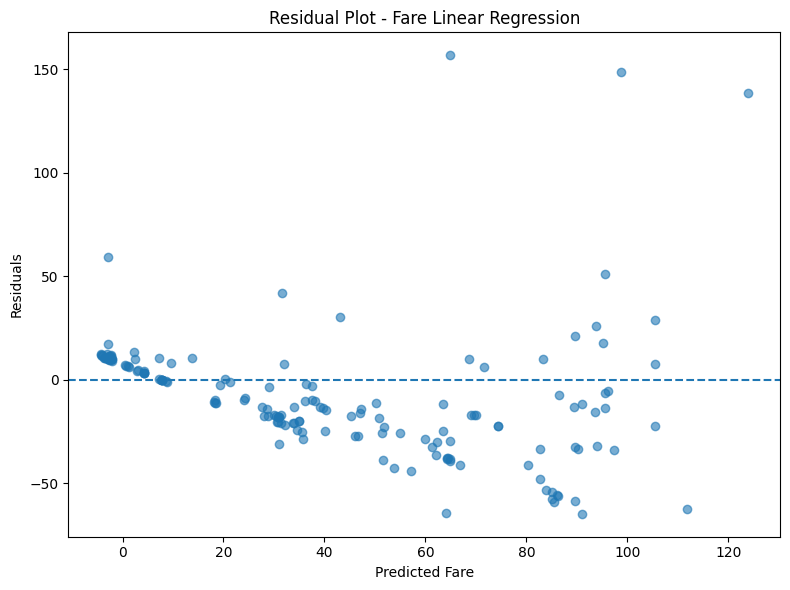

In [48]:
# ============================================================
# REGRESSION RESIDUAL ANALYSIS
# ============================================================

residuals = (
    y_reg_test - fare_predictions
)

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    fare_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Fare"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Residual Plot - Fare Linear Regression"
)

plt.tight_layout()

plt.savefig(
    "charts/fare_regression_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# ============================================================
# FINAL CLASSIFIER COMPARISON
# ============================================================

final_classification_results = []

# Original models
final_classification_results.append(
    evaluate_classifier(
        "Logistic Regression",
        logistic_pipeline,
        X_test,
        y_test
    )
)

final_classification_results.append(
    evaluate_classifier(
        "Decision Tree",
        decision_tree_pipeline,
        X_test,
        y_test
    )
)

final_classification_results.append(
    evaluate_classifier(
        "Random Forest",
        random_forest_pipeline,
        X_test,
        y_test
    )
)

# Tuned Random Forest
final_classification_results.append(
    evaluate_classifier(
        "Tuned Random Forest",
        best_rf_pipeline,
        X_test,
        y_test
    )
)

final_classifier_df = pd.DataFrame(
    final_classification_results
)

final_classifier_df = (
    final_classifier_df
    .set_index("Model")
    .round(4)
)

print("Final Classifier Comparison:")

display(final_classifier_df)

Final Classifier Comparison:


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
Decision Tree,0.7933,0.8636,0.5507,0.6726,0.8292
Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300
Tuned Random Forest,0.8156,0.8750,0.6087,0.7179,0.8431


In [50]:
# ============================================================
# FINAL REGRESSION RESULTS
# ============================================================

print("Final Fare Regression Metrics:")

display(
    regression_metrics
)

Final Fare Regression Metrics:


,Metric,Value
0,MAE,20.8094
1,RMSE,30.4731
2,R2,0.3999
3,Adjusted R2,0.3679


In [51]:
# ============================================================
# CLASSIFIER METRIC SUMMARY
# ============================================================

print(
    "Highest Accuracy:",
    final_classifier_df["Accuracy"].idxmax(),
    "-",
    final_classifier_df["Accuracy"].max()
)

print(
    "Highest Precision:",
    final_classifier_df["Precision"].idxmax(),
    "-",
    final_classifier_df["Precision"].max()
)

print(
    "Highest Recall:",
    final_classifier_df["Recall"].idxmax(),
    "-",
    final_classifier_df["Recall"].max()
)

print(
    "Highest F1:",
    final_classifier_df["F1"].idxmax(),
    "-",
    final_classifier_df["F1"].max()
)

print(
    "Highest ROC-AUC:",
    final_classifier_df["ROC_AUC"].idxmax(),
    "-",
    final_classifier_df["ROC_AUC"].max()
)

Highest Accuracy: Random Forest - 0.8156
Highest Precision: Tuned Random Forest - 0.875
Highest Recall: Random Forest - 0.6957
Highest F1: Random Forest - 0.7442
Highest ROC-AUC: Logistic Regression - 0.8437


In [52]:
# ============================================================
# SAVE FINAL FITTED PIPELINE
# ============================================================

os.makedirs(
    "models",
    exist_ok=True
)

best_pipeline = random_forest_pipeline

model_path = (
    "models/best_pipeline.joblib"
)

joblib.dump(
    best_pipeline,
    model_path
)

print(
    "Model saved successfully:"
)

print(model_path)

Model saved successfully:
models/best_pipeline.joblib


In [53]:
# ============================================================
# RELOAD SAVED PIPELINE
# ============================================================

loaded_pipeline = joblib.load(
    "models/best_pipeline.joblib"
)

print(
    "Saved pipeline loaded successfully."
)

print(loaded_pipeline)

Saved pipeline loaded successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                             

In [54]:
# ============================================================
# PREDICT USING RAW INPUT
# ============================================================

raw_passenger = pd.DataFrame(
    [
        {
            "pclass": 3,
            "sex": "male",
            "age": 25,
            "sibsp": 0,
            "parch": 0,
            "fare": 7.25,
            "embarked": "S"
        }
    ]
)

print("Raw Passenger Input:")

display(raw_passenger)

prediction = loaded_pipeline.predict(
    raw_passenger
)

probability = (
    loaded_pipeline
    .predict_proba(raw_passenger)[0, 1]
)

print(
    "\nPredicted class:",
    int(prediction[0])
)

print(
    "Survival probability:",
    round(float(probability), 4)
)

if prediction[0] == 1:
    print(
        "Prediction: Survived"
    )
else:
    print(
        "Prediction: Did Not Survive"
    )

Raw Passenger Input:


,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,25,0,0,7.25,S



Predicted class: 0
Survival probability: 0.0
Prediction: Did Not Survive


In [55]:
# ============================================================
# VERIFY GENERATED ARTIFACTS
# ============================================================

print("Model exists:")
print(
    os.path.exists(
        "models/best_pipeline.joblib"
    )
)

print("\nGenerated charts:")

for filename in sorted(
    os.listdir("charts")
):
    print("-", filename)

Model exists:
True

Generated charts:
- .ipynb_checkpoints
- age_boxplot.png
- age_class_survival.png
- age_histogram.png
- classifier_roc_curves.png
- confusion_matrix_decision_tree.png
- confusion_matrix_logistic_regression.png
- confusion_matrix_random_forest.png
- correlation_heatmap.png
- decision_tree.png
- fare_boxplot.png
- fare_class_survival.png
- fare_histogram.png
- fare_regression_residuals.png
- survival_by_class_sex.png
- survival_by_sex.png


## Final Model Evaluation and Conclusion

Three baseline classification algorithms were evaluated: Logistic Regression, Decision Tree, and Random Forest. Their performance was compared using accuracy, precision, recall, F1-score, and ROC-AUC so that model selection was not based on accuracy alone.

The class-imbalance experiment compared the baseline Logistic Regression model with `class_weight="balanced"` and SMOTE. SMOTE was applied only to the training data after preprocessing, ensuring that synthetic samples from the test set were never introduced into model training and preventing data leakage.

Random Forest was further optimized using GridSearchCV over `n_estimators`, `max_depth`, and `max_features`, with out-of-bag evaluation enabled. The tuned Random Forest achieved a test accuracy of **0.8156**, precision of **0.8750**, recall of **0.6087**, F1-score of **0.7179**, and ROC-AUC of **0.8431**. The tuning produced high precision, although the reduction in recall demonstrates the trade-off between correctly identifying positive cases and avoiding false-positive predictions.

Based on the overall classifier comparison, the baseline Random Forest pipeline was retained as the final persisted model because it provided a strong balance across the evaluation metrics, particularly F1-score. The complete preprocessing-and-classification pipeline was saved with Joblib, reloaded successfully, and verified using a raw passenger record.

## Fare Regression Conclusion

A multivariate Linear Regression model was developed to predict passenger fare using passenger class, sex, age, number of siblings/spouses, number of parents/children, and embarkation location. Missing values, categorical encoding, and numerical scaling were handled inside a preprocessing pipeline fitted using the training data.

The regression model was evaluated separately from the classification models using MAE, RMSE, R², and Adjusted R². The residual plot was also examined to determine whether the residual variance remained approximately constant across predicted fare values.

The residual analysis provides a visual check for heteroscedasticity. A systematic increase or decrease in residual spread as predicted fare changes would indicate non-constant error variance, whereas a relatively uniform random spread around zero would provide less evidence of heteroscedasticity.